# 06 - Order Fulfillment Simulator｜訂單履約與交期規劃模擬

## 分析目的

本 Notebook 將 01～05 的分析結果轉成 Planner 決策情境：

**Forecast**
→ **Demand Scenario**
→ **Capacity**
→ **Existing Load**
→ **Order Priority**
→ **Allocation**
→ **Feasible Commit Month**
→ **On Time / At Risk / Late**
→ **What-if Stress Test**

前面 Notebook 已完成：

- `01`：Data Validation
- `02`：Demand vs Shipment
- `03`：Backlog / Coverage
- `04`：3-Month Order Forecast
- `05`：Forecast Error / Bias / Planning Reference

06 不再訓練模型，而是展示 Forecast 如何進一步轉成 Capacity 與 Delivery Commitment Logic。

## 資料範圍

### Public-data analysis

04 / 05 的：

- Point Forecast
- Forecast Error
- Planning Reference

來自前面以美國電子元件製造業公開資料建立的分析。

### Synthetic Planning Scenario

本 Notebook 的：

- Monthly Capacity
- Existing Load
- Safety Reserve
- Customer Order Book
- Priority
- Requested Due Month

全部是人工設計的模擬資料。

> **不是 ASE、日月光或任何公司的內部營運資料。**

## 單位

Public Forecast：

**Millions of USD**

Synthetic Planning Scenario：

**k planning units**

兩者不直接換算，只使用 Forecast Planning Reference 相對 Point Forecast 的比例作為 Scenario Multiplier。

## Simulator 重要簡化

- Requested Due Date 只到「月份」，沒有精確到日期。
- Order Book 沒有 order release / received date，因此允許提早月份生產。
- Priority 規則為：**Due Month 優先，再以 Priority 作同月排序。**
- 一張訂單只要有部分數量排到 Due Month 之後，整張訂單 Status 就標示為 `Late`。
- `Late Quantity` 另外計算真正跨過 Due Month 的那部分數量。


## Step 1｜載入分析套件

### 這一格要做什麼？

載入：

- `Path`：專案路徑
- `numpy`：數值計算
- `pandas`：Order / Capacity 資料處理
- `matplotlib`：Capacity 圖表
- `display`：顯示表格

### 為什麼不重新載入 Forecasting 模型？

Forecast 已在 04 完成，05 也已完成 Error Evaluation。06 只讀取正式輸出，分析重點是 Planning 與 Order Allocation。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Planning libraries loaded successfully.")


Planning libraries loaded successfully.


### 輸出解讀

實際輸出：

```text
Planning libraries loaded successfully.
```

代表 06 所需的資料處理與圖表套件均成功載入。

**白話解讀：** Planning Simulator 的執行環境正常，可以直接讀取 04 / 05 的正式 Forecast 結果。

**下一步：**讀取 Point Forecast、Planning Reference 與 Forecast Evaluation Summary。


## Step 2｜讀取 04 / 05 Forecast 輸出

### 這一格要做什麼？

讀取：

- `final_3_month_order_forecast.csv`
- `forecast_planning_reference.csv`
- `forecast_evaluation_summary.csv`

其中：

- 04 提供 Point Forecast
- 05 提供 Historical Error-based Planning Reference
- 05 Evaluation Summary 提供模型 WAPE、Bias 與誤差限制

### 為什麼 Public Forecast 不直接轉成 Synthetic Units？

Public Forecast 的單位是 `Millions of USD`，Synthetic Capacity 的單位是 `k planning units`。

兩者沒有真實轉換關係，因此只使用「相對百分比變化」建立 Scenario。


In [2]:
PROJECT_ROOT = Path.cwd().parent
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

FINAL_FORECAST_PATH = (
    REPORT_TABLE_DIR
    / "final_3_month_order_forecast.csv"
)

PLANNING_REFERENCE_PATH = (
    REPORT_TABLE_DIR
    / "forecast_planning_reference.csv"
)

EVALUATION_SUMMARY_PATH = (
    REPORT_TABLE_DIR
    / "forecast_evaluation_summary.csv"
)

required_paths = [
    FINAL_FORECAST_PATH,
    PLANNING_REFERENCE_PATH,
    EVALUATION_SUMMARY_PATH,
]

missing_files = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required 04/05 outputs are missing:\n"
        + "\n".join(missing_files)
    )

final_forecast = pd.read_csv(
    FINAL_FORECAST_PATH,
    parse_dates=["date"],
)

planning_reference = pd.read_csv(
    PLANNING_REFERENCE_PATH,
    parse_dates=["date"],
)

evaluation_summary = pd.read_csv(
    EVALUATION_SUMMARY_PATH
)

print("Final forecast:")
display(final_forecast)

print("\nPlanning reference:")
display(planning_reference)

print("\nEvaluation summary:")
display(evaluation_summary)


Final forecast:


,date,last_value,seasonal_naive,holt_winters,xgboost_direct,selected_forecast
0,2026-09-01,5769.0,5132.0,5771.393496,5621.551758,5769.0
1,2026-10-01,5769.0,5264.0,5796.199388,5620.902832,5769.0
2,2026-11-01,5769.0,5288.0,5803.917358,5616.255859,5769.0



Planning reference:


,date,lower_planning_reference,selected_forecast,upper_planning_reference
0,2026-09-01,5598.270045,5769.0,5939.729955
1,2026-10-01,5598.270045,5769.0,5939.729955
2,2026-11-01,5598.270045,5769.0,5939.729955



Evaluation summary:


,metric,value
0,Selected Model,last_value
1,Pooled Backtest WAPE,1.851%
2,Aggregate Bias,-1.80%
3,Over-Forecast Count,1
4,Under-Forecast Count,17
5,Worst Horizon by MAPE,3
6,Worst Fold by WAPE,1
7,Worst Fold WAPE,3.221%
8,Maximum Single-Month APE,4.29%
9,80th Percentile APE,2.96%


### 輸出解讀

04 Final Forecast：

| Month | Selected Forecast |
|---|---:|
| 2026-09 | **5,769** |
| 2026-10 | **5,769** |
| 2026-11 | **5,769** |

05 Planning Reference：

| Month | Lower | Point | Upper |
|---|---:|---:|---:|
| 2026-09 | 5,598.27 | 5,769 | 5,939.73 |
| 2026-10 | 5,598.27 | 5,769 | 5,939.73 |
| 2026-11 | 5,598.27 | 5,769 | 5,939.73 |

Forecast Evaluation：

- Selected Model = **Last Value**
- Pooled WAPE = **1.851%**
- Aggregate Bias = **-1.80%**
- Under-Forecast = **17 / 18**
- Worst Horizon = **H3**
- 80th Percentile APE = **2.96%**

### 白話解讀

Point Forecast 本身維持 5,769，但 05 已確認 Last Value 有明顯 Under-Forecast Bias。

因此 06 不只使用 Point Scenario，也額外測試 Upper Planning Reference 與 +10% Stress Scenario。

**下一步：**把 Upper Planning Reference 轉成可套用在 Synthetic Order Quantity 的相對倍率。


## Step 3｜建立 Forecast Scenario Multiplier

### 這一格要做什麼？

計算：

`Upper Multiplier = Upper Planning Reference / Point Forecast`

以及：

`Lower Multiplier = Lower Planning Reference / Point Forecast`

### 為什麼只使用倍率？

公開 Forecast 與 Synthetic Order Quantity 單位不同，因此倍率只代表「相對需求變化」，不進行不存在依據的金額轉產量換算。


In [3]:
scenario_reference = (
    planning_reference
    .merge(
        final_forecast[
            ["date", "selected_forecast"]
        ],
        on="date",
        how="inner",
        suffixes=(
            "_reference",
            "_forecast",
        ),
    )
)

scenario_reference[
    "upper_multiplier"
] = (
    scenario_reference[
        "upper_planning_reference"
    ]
    / scenario_reference[
        "selected_forecast_forecast"
    ]
)

scenario_reference[
    "lower_multiplier"
] = (
    scenario_reference[
        "lower_planning_reference"
    ]
    / scenario_reference[
        "selected_forecast_forecast"
    ]
)

scenario_reference_display = scenario_reference[
    [
        "date",
        "selected_forecast_forecast",
        "lower_planning_reference",
        "upper_planning_reference",
        "lower_multiplier",
        "upper_multiplier",
    ]
].copy()

scenario_reference_numeric_columns = (
    scenario_reference_display
    .select_dtypes(include="number")
    .columns
)

scenario_reference_display[
    scenario_reference_numeric_columns
] = (
    scenario_reference_display[
        scenario_reference_numeric_columns
    ]
    .round(4)
)

display(
    scenario_reference_display
)

UPPER_REFERENCE_MULTIPLIER = float(
    scenario_reference[
        "upper_multiplier"
    ].mean()
)

print()
print(
    "Average upper-reference multiplier:",
    f"{UPPER_REFERENCE_MULTIPLIER:.4f}",
)


,date,selected_forecast_forecast,lower_planning_reference,upper_planning_reference,lower_multiplier,upper_multiplier
0,2026-09-01,5769.0,5598.27,5939.73,0.9704,1.0296
1,2026-10-01,5769.0,5598.27,5939.73,0.9704,1.0296
2,2026-11-01,5769.0,5598.27,5939.73,0.9704,1.0296



Average upper-reference multiplier: 1.0296


### 輸出解讀

三個月份的結果完全一致：

- Lower Multiplier = **0.9704**
- Upper Multiplier = **1.0296**

平均 Upper Reference Multiplier：

```text
1.0296
```

### 白話解讀

Upper Scenario 相當於：

> Synthetic Order Quantity 約增加 **2.96%**。

例如 Point Scenario 100 k units，在 Upper Scenario 約變成 102.96 k units。

這個 +2.96% 來自 05 的 Historical Error Reference，不代表需求真的有 80% 機率增加 2.96%。

**下一步：**建立可供訂單排程使用的 Synthetic Monthly Capacity。


## Step 4｜建立 Synthetic Monthly Capacity Plan

### 這一格要做什麼？

設定：

- Total Capacity
- Existing Load
- Safety Reserve
- Net New Order Capacity

公式：

`Net New Order Capacity = Total Capacity - Existing Load - Safety Reserve`

### Safety Reserve 的作用

保留部分產能，不分配給一般新訂單，用來模擬：

- downtime
- rework
- urgent order
- production variability

### 注意

以下 Capacity 數字全部是 Synthetic。


In [4]:
capacity_plan = pd.DataFrame(
    {
        "month": pd.to_datetime(
            [
                "2026-09-01",
                "2026-10-01",
                "2026-11-01",
                "2026-12-01",
            ]
        ),
        "total_capacity": [
            600.0,
            620.0,
            610.0,
            630.0,
        ],
        "existing_load": [
            360.0,
            380.0,
            350.0,
            380.0,
        ],
        "safety_reserve": [
            30.0,
            30.0,
            30.0,
            30.0,
        ],
    }
)

capacity_plan[
    "net_new_order_capacity"
] = (
    capacity_plan["total_capacity"]
    - capacity_plan["existing_load"]
    - capacity_plan["safety_reserve"]
)

print(
    "Synthetic capacity scenario — not company internal data."
)

display(capacity_plan)


Synthetic capacity scenario — not company internal data.


,month,total_capacity,existing_load,safety_reserve,net_new_order_capacity
0,2026-09-01,600.0,360.0,30.0,210.0
1,2026-10-01,620.0,380.0,30.0,210.0
2,2026-11-01,610.0,350.0,30.0,230.0
3,2026-12-01,630.0,380.0,30.0,220.0


### 輸出解讀

Synthetic Net New Order Capacity：

| Month | Total Capacity | Existing Load | Safety Reserve | Net New-Order Capacity |
|---|---:|---:|---:|---:|
| 2026-09 | 600 | 360 | 30 | **210** |
| 2026-10 | 620 | 380 | 30 | **210** |
| 2026-11 | 610 | 350 | 30 | **230** |
| 2026-12 | 630 | 380 | 30 | **220** |

### 白話解讀

9～11 月總共有：

**210 + 210 + 230 = 650 k units**

可分配給新訂單。

12 月另外保留 **220 k units**，可用來觀察前面月份若排不完，是否產生跨月 Spillover。

**下一步：**建立總量剛好接近 9～11 月 Net Capacity 的 Synthetic Order Book。


## Step 5｜建立 Synthetic Customer Order Book

### 這一格要做什麼？

建立 6 筆模擬 Customer Orders，包含：

- Order ID
- Customer
- Quantity
- Requested Due Month
- Priority

排序規則：

1. Requested Due Month 較早者優先
2. 同一 Due Month 中 High Priority 優先
3. 再以 Order ID 排序

### 注意

Customer、Quantity、Priority 與 Due Month 均為人工建立。


In [5]:
order_book = pd.DataFrame(
    {
        "order_id": [
            "O001",
            "O002",
            "O003",
            "O004",
            "O005",
            "O006",
        ],
        "customer": [
            "Customer_A",
            "Customer_B",
            "Customer_C",
            "Customer_D",
            "Customer_E",
            "Customer_F",
        ],
        "quantity": [
            120.0,
            60.0,
            130.0,
            100.0,
            150.0,
            90.0,
        ],
        "requested_due_month": pd.to_datetime(
            [
                "2026-09-01",
                "2026-09-01",
                "2026-10-01",
                "2026-10-01",
                "2026-11-01",
                "2026-11-01",
            ]
        ),
        "priority": [
            "High",
            "Normal",
            "High",
            "Normal",
            "High",
            "Normal",
        ],
    }
)

print(
    "Synthetic customer order book — not company internal data."
)

display(order_book)

print()
print(
    "Total synthetic order quantity:",
    order_book["quantity"].sum(),
    "k units",
)


Synthetic customer order book — not company internal data.


,order_id,customer,quantity,requested_due_month,priority
0,O001,Customer_A,120.0,2026-09-01,High
1,O002,Customer_B,60.0,2026-09-01,Normal
2,O003,Customer_C,130.0,2026-10-01,High
3,O004,Customer_D,100.0,2026-10-01,Normal
4,O005,Customer_E,150.0,2026-11-01,High
5,O006,Customer_F,90.0,2026-11-01,Normal



Total synthetic order quantity: 650.0 k units


### 輸出解讀

Synthetic Order Book：

| Order | Qty | Due Month | Priority |
|---|---:|---|---|
| O001 | 120 | Sep | High |
| O002 | 60 | Sep | Normal |
| O003 | 130 | Oct | High |
| O004 | 100 | Oct | Normal |
| O005 | 150 | Nov | High |
| O006 | 90 | Nov | Normal |

總需求：

```text
650.0 k units
```

### 白話解讀

Point Scenario 的 Synthetic Demand **650 k units**，剛好等於 9～11 月可分配的新訂單 Capacity：

**210 + 210 + 230 = 650**

因此 Base Plan 本身就沒有多餘的新訂單 Capacity Buffer。

這個設計可以直接測試：

> 需求只要稍微高於 Point Scenario，是否會開始 Spillover 到 12 月。

**下一步：**在正式排程前先驗證 Synthetic Scenario 的基本規則。


## Step 6｜Synthetic Scenario Validation

### 這一格要做什麼？

檢查：

- Total Capacity > 0
- Existing Load + Reserve 不超過 Capacity
- Net Capacity 不為負
- Order Quantity > 0
- Order ID 不重複
- Priority 值合法
- Requested Due Month 位於 Planning Horizon

### 為什麼 Synthetic Data 也要驗證？

即使是模擬情境，若 Capacity 或 Order 資料本身不合理，後面的 Allocation 結果也沒有解讀價值。


In [6]:
if (
    capacity_plan["total_capacity"] <= 0
).any():
    raise ValueError(
        "Total capacity must be positive."
    )

if (
    capacity_plan[
        "existing_load"
    ]
    + capacity_plan[
        "safety_reserve"
    ]
    > capacity_plan[
        "total_capacity"
    ]
).any():
    raise ValueError(
        "Existing load plus reserve exceeds total capacity."
    )

if (
    capacity_plan[
        "net_new_order_capacity"
    ]
    < 0
).any():
    raise ValueError(
        "Net new-order capacity cannot be negative."
    )

if (
    order_book["quantity"] <= 0
).any():
    raise ValueError(
        "Order quantity must be positive."
    )

if order_book[
    "order_id"
].duplicated().any():
    raise ValueError(
        "Order IDs must be unique."
    )

allowed_priorities = {
    "High",
    "Normal",
}

if not set(
    order_book["priority"]
).issubset(
    allowed_priorities
):
    raise ValueError(
        "Unexpected priority value."
    )

planning_months = set(
    capacity_plan["month"]
)

if not set(
    order_book[
        "requested_due_month"
    ]
).issubset(
    planning_months
):
    raise ValueError(
        "Due month is outside the planning horizon."
    )

print("SYNTHETIC SCENARIO CHECK: PASS")


SYNTHETIC SCENARIO CHECK: PASS


### 輸出解讀

實際輸出：

```text
SYNTHETIC SCENARIO CHECK: PASS
```

代表：

- Capacity 沒有負值
- Existing Load + Reserve 沒有超過 Total Capacity
- 6 筆 Order Quantity 都為正
- Order ID 沒有重複
- Priority 只有 High / Normal
- Due Month 全部落在 Capacity Planning Horizon

**白話解讀：** Synthetic Inputs 通過基本規則檢查，可以開始執行 Allocation。

**下一步：**建立透明、可追蹤的 Order Allocation Function。


## Step 7｜建立 Order Allocation Function

### 排程邏輯

訂單先依：

1. Requested Due Month
2. Priority
3. Order ID

排序。

接著從最早 Planning Month 開始使用剩餘 Net Capacity。

### Split Allocation

Order 可拆到不同月份。

例如某訂單 130 k units：

- Sep 可用 30
- Oct 可用 100

則 Final Commit Month = Oct。

### Status 定義

- `On Time`：Final Commit Month 不晚於 Due Month，且完成該訂單後該月 Slack ≥ 10%
- `At Risk`：Final Commit Month = Due Month，但完成該訂單後 Slack < 10%
- `Late`：Final Commit Month 晚於 Due Month
- `Unscheduled`：Planning Horizon 結束仍有數量排不完

### 重要簡化

- 沒有 Order Release Date，因此允許比 Requested Due Month 提早生產。
- Priority 只在相同 Due Month 的訂單之間決定先後。
- Status 看的是該訂單最後一部分完成的月份。


In [7]:
PRIORITY_RANK = {
    "High": 0,
    "Normal": 1,
}

AT_RISK_SLACK_THRESHOLD = 0.10


def allocate_orders(
    orders: pd.DataFrame,
    capacity: pd.DataFrame,
    quantity_multiplier: float = 1.0,
    scenario_name: str = "Point",
):

    capacity_work = (
        capacity
        .copy()
        .sort_values("month")
        .reset_index(drop=True)
    )

    capacity_remaining = {
        row.month: float(
            row.net_new_order_capacity
        )
        for row in capacity_work.itertuples()
    }

    net_capacity_lookup = {
        row.month: float(
            row.net_new_order_capacity
        )
        for row in capacity_work.itertuples()
    }

    order_work = orders.copy()

    order_work[
        "priority_rank"
    ] = order_work[
        "priority"
    ].map(
        PRIORITY_RANK
    )

    order_work = (
        order_work
        .sort_values(
            [
                "requested_due_month",
                "priority_rank",
                "order_id",
            ]
        )
        .reset_index(drop=True)
    )

    allocation_records = []
    order_summary_records = []

    planning_months_sorted = sorted(
        capacity_remaining.keys()
    )

    for order in order_work.itertuples():

        adjusted_quantity = float(
            order.quantity
            * quantity_multiplier
        )

        remaining_quantity = (
            adjusted_quantity
        )

        final_commit_month = pd.NaT
        slack_after_commit_pct = np.nan

        for month in planning_months_sorted:

            if remaining_quantity <= 1e-9:
                break

            available = (
                capacity_remaining[
                    month
                ]
            )

            if available <= 1e-9:
                continue

            allocated = min(
                remaining_quantity,
                available,
            )

            capacity_remaining[
                month
            ] -= allocated

            remaining_quantity -= allocated

            allocation_records.append(
                {
                    "scenario": scenario_name,
                    "order_id": order.order_id,
                    "customer": order.customer,
                    "priority": order.priority,
                    "requested_due_month": (
                        order.requested_due_month
                    ),
                    "allocation_month": month,
                    "allocated_quantity": allocated,
                }
            )

            final_commit_month = month

            slack_after_commit_pct = (
                capacity_remaining[month]
                / net_capacity_lookup[
                    month
                ]
            )

        if remaining_quantity > 1e-9:

            status = "Unscheduled"

        elif (
            final_commit_month
            > order.requested_due_month
        ):

            status = "Late"

        elif (
            final_commit_month
            == order.requested_due_month
            and slack_after_commit_pct
            < AT_RISK_SLACK_THRESHOLD
        ):

            status = "At Risk"

        else:

            status = "On Time"

        order_summary_records.append(
            {
                "scenario": scenario_name,
                "order_id": order.order_id,
                "customer": order.customer,
                "priority": order.priority,
                "base_quantity": (
                    float(order.quantity)
                ),
                "scenario_quantity": (
                    adjusted_quantity
                ),
                "requested_due_month": (
                    order.requested_due_month
                ),
                "feasible_commit_month": (
                    final_commit_month
                ),
                "remaining_unscheduled": (
                    max(
                        remaining_quantity,
                        0.0,
                    )
                ),
                "slack_after_commit_pct": (
                    slack_after_commit_pct
                ),
                "status": status,
            }
        )

    allocation_detail = pd.DataFrame(
        allocation_records
    )

    order_summary = pd.DataFrame(
        order_summary_records
    )

    monthly_allocated = (
        allocation_detail
        .groupby(
            "allocation_month",
            as_index=False,
        )[
            "allocated_quantity"
        ]
        .sum()
        .rename(
            columns={
                "allocation_month": "month",
                "allocated_quantity": (
                    "allocated_new_orders"
                ),
            }
        )
    )

    capacity_result = (
        capacity_work
        .merge(
            monthly_allocated,
            on="month",
            how="left",
        )
    )

    capacity_result[
        "allocated_new_orders"
    ] = (
        capacity_result[
            "allocated_new_orders"
        ]
        .fillna(0.0)
    )

    capacity_result[
        "remaining_new_order_capacity"
    ] = (
        capacity_result[
            "net_new_order_capacity"
        ]
        - capacity_result[
            "allocated_new_orders"
        ]
    )

    capacity_result[
        "new_order_capacity_utilization_pct"
    ] = (
        capacity_result[
            "allocated_new_orders"
        ]
        / capacity_result[
            "net_new_order_capacity"
        ]
        * 100
    )

    capacity_result[
        "operational_load_pct"
    ] = (
        (
            capacity_result[
                "existing_load"
            ]
            + capacity_result[
                "allocated_new_orders"
            ]
        )
        / capacity_result[
            "total_capacity"
        ]
        * 100
    )

    return (
        allocation_detail,
        order_summary,
        capacity_result,
    )


print(
    "Order allocation function created successfully."
)


Order allocation function created successfully.


### 輸出解讀

實際輸出：

```text
Order allocation function created successfully.
```

代表 Function 已具備：

- Due Month / Priority 排序
- Split Allocation
- Capacity Consumption
- Feasible Commit Month
- On Time / At Risk / Late / Unscheduled
- Monthly Capacity Utilization

目前只是建立規則，尚未執行 Scenario。

**下一步：**先用 1.00 倍需求執行 Point Scenario。


## Step 8｜執行 Point Demand Scenario

### Scenario 定義

`Demand Multiplier = 1.00`

Synthetic Demand 保持原始：

**650 k units**

### 這一格要回答什麼？

- 6 筆訂單能不能在 Requested Due Month 前完成？
- 哪些訂單已經接近 Capacity Limit？
- 哪些月份的新訂單 Capacity 被用滿？


In [8]:
(
    point_allocation,
    point_order_summary,
    point_capacity_result,
) = allocate_orders(
    orders=order_book,
    capacity=capacity_plan,
    quantity_multiplier=1.0,
    scenario_name="Point Forecast",
)

print("POINT SCENARIO — ORDER SUMMARY")
display(
    point_order_summary.round(
        {
            "base_quantity": 2,
            "scenario_quantity": 2,
            "remaining_unscheduled": 2,
            "slack_after_commit_pct": 3,
        }
    )
)

print("\nPOINT SCENARIO — CAPACITY")
point_capacity_display = (
    point_capacity_result.copy()
)

point_capacity_numeric_columns = (
    point_capacity_display
    .select_dtypes(include="number")
    .columns
)

point_capacity_display[
    point_capacity_numeric_columns
] = (
    point_capacity_display[
        point_capacity_numeric_columns
    ]
    .round(2)
)

display(
    point_capacity_display
)


POINT SCENARIO — ORDER SUMMARY


,scenario,order_id,customer,priority,base_quantity,scenario_quantity,requested_due_month,feasible_commit_month,remaining_unscheduled,slack_after_commit_pct,status
0,Point Forecast,O001,Customer_A,High,120.0,120.0,2026-09-01,2026-09-01,0.0,0.429,On Time
1,Point Forecast,O002,Customer_B,Normal,60.0,60.0,2026-09-01,2026-09-01,0.0,0.143,On Time
2,Point Forecast,O003,Customer_C,High,130.0,130.0,2026-10-01,2026-10-01,0.0,0.524,On Time
3,Point Forecast,O004,Customer_D,Normal,100.0,100.0,2026-10-01,2026-10-01,0.0,0.048,At Risk
4,Point Forecast,O005,Customer_E,High,150.0,150.0,2026-11-01,2026-11-01,0.0,0.391,On Time
5,Point Forecast,O006,Customer_F,Normal,90.0,90.0,2026-11-01,2026-11-01,0.0,0.000,At Risk



POINT SCENARIO — CAPACITY


,month,total_capacity,existing_load,safety_reserve,net_new_order_capacity,allocated_new_orders,remaining_new_order_capacity,new_order_capacity_utilization_pct,operational_load_pct
0,2026-09-01,600.0,360.0,30.0,210.0,210.0,0.0,100.0,95.00
1,2026-10-01,620.0,380.0,30.0,210.0,210.0,0.0,100.0,95.16
2,2026-11-01,610.0,350.0,30.0,230.0,230.0,0.0,100.0,95.08
3,2026-12-01,630.0,380.0,30.0,220.0,0.0,220.0,0.0,60.32


### 輸出解讀

Point Scenario 訂單結果：

| Order | Due | Commit | Slack after commit | Status |
|---|---|---|---:|---|
| O001 | Sep | Sep | 42.9% | On Time |
| O002 | Sep | Sep | 14.3% | On Time |
| O003 | Oct | Oct | 52.4% | On Time |
| O004 | Oct | Oct | **4.8%** | **At Risk** |
| O005 | Nov | Nov | 39.1% | On Time |
| O006 | Nov | Nov | **0.0%** | **At Risk** |

Point Capacity：

| Month | Net Capacity | Allocated | Remaining | New-order Utilization |
|---|---:|---:|---:|---:|
| Sep | 210 | 210 | 0 | **100%** |
| Oct | 210 | 210 | 0 | **100%** |
| Nov | 230 | 230 | 0 | **100%** |
| Dec | 220 | 0 | 220 | 0% |

### 白話解讀

Point Scenario 沒有 Late Order，但已經沒有真正的 9～11 月 New Order Capacity Buffer。

O004 與 O006 雖然仍能在 Requested Due Month 完成，但完成時剩餘 Slack 分別只有：

- O004：**4.8%**
- O006：**0%**

因此被標記為 `At Risk`。

另外，`New-order Utilization = 100%` 不代表 Total Factory Capacity 使用率 100%。Safety Reserve 仍被刻意保留，所以 Operational Load 約為 95%。

**下一步：**查看 Split Allocation，確認 650 k units 如何跨月份排入。


## Step 9｜查看 Point Scenario Allocation Detail

### 這一格要做什麼？

顯示每張訂單真正被排到哪些月份。

一張 Order 可以出現多列，代表 Quantity 被拆成不同月份生產。

### 為什麼需要看 Detail？

Order Summary 只顯示 Final Commit Month；Allocation Detail 才能確認該 Commit Month 是如何由每月 Capacity 推導出來。


In [9]:
display(
    point_allocation.round(
        {
            "allocated_quantity": 2,
        }
    )
)

point_status_summary = (
    point_order_summary[
        "status"
    ]
    .value_counts()
    .reindex(
        [
            "On Time",
            "At Risk",
            "Late",
            "Unscheduled",
        ],
        fill_value=0,
    )
)

print("\nPoint scenario status:")
print(point_status_summary)


,scenario,order_id,customer,priority,requested_due_month,allocation_month,allocated_quantity
0,Point Forecast,O001,Customer_A,High,2026-09-01,2026-09-01,120.0
1,Point Forecast,O002,Customer_B,Normal,2026-09-01,2026-09-01,60.0
2,Point Forecast,O003,Customer_C,High,2026-10-01,2026-09-01,30.0
3,Point Forecast,O003,Customer_C,High,2026-10-01,2026-10-01,100.0
4,Point Forecast,O004,Customer_D,Normal,2026-10-01,2026-10-01,100.0
5,Point Forecast,O005,Customer_E,High,2026-11-01,2026-10-01,10.0
6,Point Forecast,O005,Customer_E,High,2026-11-01,2026-11-01,140.0
7,Point Forecast,O006,Customer_F,Normal,2026-11-01,2026-11-01,90.0



Point scenario status:
status
On Time        4
At Risk        2
Late           0
Unscheduled    0
Name: count, dtype: int64


### 輸出解讀

Point Allocation：

- O001：Sep 120
- O002：Sep 60
- O003：Sep 30 + Oct 100
- O004：Oct 100
- O005：Oct 10 + Nov 140
- O006：Nov 90

因此：

- Sep = 120 + 60 + 30 = **210**
- Oct = 100 + 100 + 10 = **210**
- Nov = 140 + 90 = **230**

三個月全部剛好填滿 Net New Order Capacity。

Status Count：

```text
On Time        4
At Risk        2
Late           0
Unscheduled    0
```

### 白話解讀

Point Scenario 能做到 0 Late，部分原因是 Simulator 允許提早生產：

- O003 的 30 units 提早在 Sep 生產
- O005 的 10 units 提早在 Oct 生產

即使如此，Sep～Nov Capacity 仍全部用滿，因此 Base Plan 屬於「可以履約，但 Buffer 很低」的情況。

**下一步：**用 Capacity 圖確認三個月是否確實滿載。


## Step 10｜繪製 Point Scenario Capacity Loading

### 這一格要做什麼？

比較每月：

- Net New-Order Capacity
- Allocated New Orders

### 圖表目的

快速辨識哪個月份已經沒有額外的新訂單排程空間。


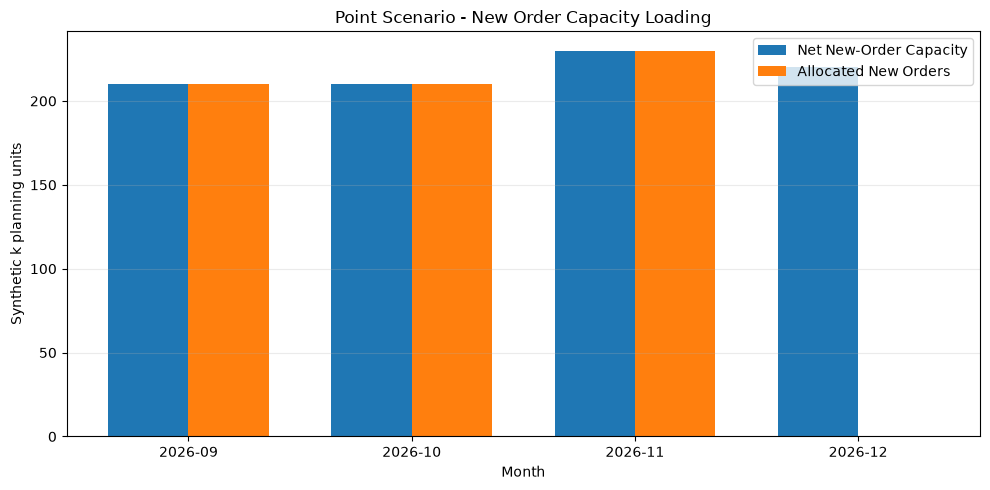

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\06_point_scenario_capacity_loading.png


In [10]:
REPORT_FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

x = np.arange(
    len(point_capacity_result)
)

width = 0.36

ax.bar(
    x - width / 2,
    point_capacity_result[
        "net_new_order_capacity"
    ],
    width=width,
    label="Net New-Order Capacity",
)

ax.bar(
    x + width / 2,
    point_capacity_result[
        "allocated_new_orders"
    ],
    width=width,
    label="Allocated New Orders",
)

ax.set_xticks(x)

ax.set_xticklabels(
    point_capacity_result[
        "month"
    ].dt.strftime("%Y-%m")
)

ax.set_title(
    "Point Scenario - New Order Capacity Loading"
)
ax.set_xlabel("Month")
ax.set_ylabel("Synthetic k planning units")
ax.legend()
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "06_point_scenario_capacity_loading.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

Point Scenario 圖表對應的實際數值：

- Sep：210 / 210
- Oct：210 / 210
- Nov：230 / 230
- Dec：0 / 220

### 白話解讀

Sep～Nov 的 Allocated Orders 都等於 Net New-Order Capacity，代表這三個月份全部滿載。

12 月仍完全空著，因此如果需求高於 Point Scenario，最直接的結果就是部分原本 9～11 月到期的訂單往 12 月 Spillover。

**下一步：**用 +2.96% Upper Planning Reference 測試這個敏感度。


## Step 11｜執行 Upper Planning Reference Scenario

### Scenario 定義

Demand Multiplier：

**1.0296**

也就是 Synthetic Demand 約比 Point Scenario 高 **2.96%**。

這個倍率來自 05 的 80th Percentile Historical APE。

### 分析目的

檢查只有約 3% 的需求上修，是否就足以讓 Point Scenario 的 Capacity Buffer 消失並產生 Late Order。


In [11]:
(
    upper_allocation,
    upper_order_summary,
    upper_capacity_result,
) = allocate_orders(
    orders=order_book,
    capacity=capacity_plan,
    quantity_multiplier=(
        UPPER_REFERENCE_MULTIPLIER
    ),
    scenario_name="Upper Planning Reference",
)

print(
    "UPPER PLANNING REFERENCE — ORDER SUMMARY"
)

display(
    upper_order_summary.round(
        {
            "base_quantity": 2,
            "scenario_quantity": 2,
            "remaining_unscheduled": 2,
            "slack_after_commit_pct": 3,
        }
    )
)

print(
    "\nUPPER PLANNING REFERENCE — CAPACITY"
)

upper_capacity_display = (
    upper_capacity_result.copy()
)

upper_capacity_numeric_columns = (
    upper_capacity_display
    .select_dtypes(include="number")
    .columns
)

upper_capacity_display[
    upper_capacity_numeric_columns
] = (
    upper_capacity_display[
        upper_capacity_numeric_columns
    ]
    .round(2)
)

display(
    upper_capacity_display
)


UPPER PLANNING REFERENCE — ORDER SUMMARY


,scenario,order_id,customer,priority,base_quantity,scenario_quantity,requested_due_month,feasible_commit_month,remaining_unscheduled,slack_after_commit_pct,status
0,Upper Planning Reference,O001,Customer_A,High,120.0,123.55,2026-09-01,2026-09-01,0.0,0.412,On Time
1,Upper Planning Reference,O002,Customer_B,Normal,60.0,61.78,2026-09-01,2026-09-01,0.0,0.117,On Time
2,Upper Planning Reference,O003,Customer_C,High,130.0,133.85,2026-10-01,2026-10-01,0.0,0.480,On Time
3,Upper Planning Reference,O004,Customer_D,Normal,100.0,102.96,2026-10-01,2026-11-01,0.0,0.991,Late
4,Upper Planning Reference,O005,Customer_E,High,150.0,154.44,2026-11-01,2026-11-01,0.0,0.319,On Time
5,Upper Planning Reference,O006,Customer_F,Normal,90.0,92.66,2026-11-01,2026-12-01,0.0,0.913,Late



UPPER PLANNING REFERENCE — CAPACITY


,month,total_capacity,existing_load,safety_reserve,net_new_order_capacity,allocated_new_orders,remaining_new_order_capacity,new_order_capacity_utilization_pct,operational_load_pct
0,2026-09-01,600.0,360.0,30.0,210.0,210.00,0.00,100.00,95.00
1,2026-10-01,620.0,380.0,30.0,210.0,210.00,0.00,100.00,95.16
2,2026-11-01,610.0,350.0,30.0,230.0,230.00,0.00,100.00,95.08
3,2026-12-01,630.0,380.0,30.0,220.0,19.24,200.76,8.74,63.37


### 輸出解讀

Upper Scenario 總需求約：

**669.24 k units**

比 Point Scenario 多約：

**19.24 k units**

訂單結果：

- O001：On Time
- O002：On Time
- O003：On Time
- **O004：Late，Due Oct → Commit Nov**
- O005：On Time
- **O006：Late，Due Nov → Commit Dec**

Capacity：

- Sep：210 / 210 = 100%
- Oct：210 / 210 = 100%
- Nov：230 / 230 = 100%
- Dec：**19.24 / 220**

### 白話解讀

需求只比 Point Scenario 高約 **2.96%**，就有兩張 Normal Priority Order 跨過 Requested Due Month。

其中：

- O004 只有約 **2.13 k units** 被推到 Nov
- O006 約 **19.24 k units** 被推到 Dec

所以 `2 Late Orders` 不代表兩張訂單的全部數量都延遲；Status 只要最後一部分跨過 Due Month，就會標記整張訂單為 Late。

這顯示 Synthetic Base Plan 對小幅 Demand Upside 已相當敏感。

**下一步：**再用人工 +10% Demand Stress 測試更大的壓力情境。


## Step 12｜執行 +10% Demand Stress Test

### Scenario 定義

`Demand Multiplier = 1.10`

這不是 Forecast，而是人工 What-if Stress Test。

### 分析目的

測試如果需求比 Point Scenario 高 10%，Capacity Spillover、At-Risk 與 Late Quantity 會增加到什麼程度。


In [12]:
STRESS_MULTIPLIER = 1.10

(
    stress_allocation,
    stress_order_summary,
    stress_capacity_result,
) = allocate_orders(
    orders=order_book,
    capacity=capacity_plan,
    quantity_multiplier=(
        STRESS_MULTIPLIER
    ),
    scenario_name="+10% Demand Stress",
)

print("+10% DEMAND STRESS — ORDER SUMMARY")

display(
    stress_order_summary.round(
        {
            "base_quantity": 2,
            "scenario_quantity": 2,
            "remaining_unscheduled": 2,
            "slack_after_commit_pct": 3,
        }
    )
)


+10% DEMAND STRESS — ORDER SUMMARY


,scenario,order_id,customer,priority,base_quantity,scenario_quantity,requested_due_month,feasible_commit_month,remaining_unscheduled,slack_after_commit_pct,status
0,+10% Demand Stress,O001,Customer_A,High,120.0,132.0,2026-09-01,2026-09-01,0.0,0.371,On Time
1,+10% Demand Stress,O002,Customer_B,Normal,60.0,66.0,2026-09-01,2026-09-01,0.0,0.057,At Risk
2,+10% Demand Stress,O003,Customer_C,High,130.0,143.0,2026-10-01,2026-10-01,0.0,0.376,On Time
3,+10% Demand Stress,O004,Customer_D,Normal,100.0,110.0,2026-10-01,2026-11-01,0.0,0.865,Late
4,+10% Demand Stress,O005,Customer_E,High,150.0,165.0,2026-11-01,2026-11-01,0.0,0.148,On Time
5,+10% Demand Stress,O006,Customer_F,Normal,90.0,99.0,2026-11-01,2026-12-01,0.0,0.705,Late


### 輸出解讀

+10% Stress 總需求：

**715 k units**

訂單結果：

- O001：On Time
- **O002：At Risk**
- O003：On Time
- **O004：Late，Due Oct → Commit Nov**
- O005：On Time
- **O006：Late，Due Nov → Commit Dec**

其中：

- O002 完成後 Slack 只剩 **5.7%**
- O004 有 **31 k units** 排到 Nov
- O006 有 **65 k units** 排到 Dec

### 白話解讀

Demand 從 Point Scenario 增加 10% 後：

- Late Order 數量仍是 2
- 但真正跨過 Due Month 的 Late Quantity 顯著增加
- O002 也從 On Time 變成 At Risk

這代表只看「Late Order Count」會低估 Scenario 惡化程度，還必須一起看 Late Quantity 與 Spillover Quantity。

**下一步：**把三個 Scenario 用一致 KPI 放在同一張表。


## Step 13｜建立 Scenario Summary

### 這一格要做什麼？

對每個 Scenario 統一計算：

- Demand Multiplier
- Total Demand
- On-Time Orders
- At-Risk Orders
- Late Orders
- Unscheduled Orders
- Late Quantity
- Peak New-Order Utilization
- December Spillover

### 為什麼不只看 Late Order Count？

兩個 Scenario 都可能有 2 張 Late Order，但每張訂單真正延遲的 Quantity 可能完全不同。

因此 `Late Quantity` 和 `December Spillover` 是必要補充指標。


In [13]:
def summarize_scenario(
    scenario_name: str,
    multiplier: float,
    order_summary: pd.DataFrame,
    allocation_detail: pd.DataFrame,
    capacity_result: pd.DataFrame,
) -> dict:

    status_counts = (
        order_summary["status"]
        .value_counts()
    )

    late_order_ids = set(
        order_summary.loc[
            order_summary["status"]
            .eq("Late"),
            "order_id",
        ]
    )

    late_quantity = float(
        allocation_detail.loc[
            (
                allocation_detail[
                    "order_id"
                ].isin(
                    late_order_ids
                )
            )
            & (
                allocation_detail[
                    "allocation_month"
                ]
                > allocation_detail[
                    "requested_due_month"
                ]
            ),
            "allocated_quantity",
        ].sum()
    )

    december_month = pd.Timestamp(
        "2026-12-01"
    )

    december_spillover = float(
        allocation_detail.loc[
            allocation_detail[
                "allocation_month"
            ].eq(
                december_month
            ),
            "allocated_quantity",
        ].sum()
    )

    return {
        "scenario": scenario_name,
        "demand_multiplier": multiplier,
        "total_demand": float(
            order_summary[
                "scenario_quantity"
            ].sum()
        ),
        "on_time_orders": int(
            status_counts.get(
                "On Time",
                0,
            )
        ),
        "at_risk_orders": int(
            status_counts.get(
                "At Risk",
                0,
            )
        ),
        "late_orders": int(
            status_counts.get(
                "Late",
                0,
            )
        ),
        "unscheduled_orders": int(
            status_counts.get(
                "Unscheduled",
                0,
            )
        ),
        "late_quantity": late_quantity,
        "peak_new_order_utilization_pct": float(
            capacity_result[
                "new_order_capacity_utilization_pct"
            ].max()
        ),
        "december_spillover_quantity": (
            december_spillover
        ),
    }


scenario_summary = pd.DataFrame(
    [
        summarize_scenario(
            scenario_name="Point Forecast",
            multiplier=1.0,
            order_summary=(
                point_order_summary
            ),
            allocation_detail=(
                point_allocation
            ),
            capacity_result=(
                point_capacity_result
            ),
        ),
        summarize_scenario(
            scenario_name=(
                "Upper Planning Reference"
            ),
            multiplier=(
                UPPER_REFERENCE_MULTIPLIER
            ),
            order_summary=(
                upper_order_summary
            ),
            allocation_detail=(
                upper_allocation
            ),
            capacity_result=(
                upper_capacity_result
            ),
        ),
        summarize_scenario(
            scenario_name=(
                "+10% Demand Stress"
            ),
            multiplier=(
                STRESS_MULTIPLIER
            ),
            order_summary=(
                stress_order_summary
            ),
            allocation_detail=(
                stress_allocation
            ),
            capacity_result=(
                stress_capacity_result
            ),
        ),
    ]
)

scenario_summary_display = (
    scenario_summary.copy()
)

scenario_summary_numeric_columns = (
    scenario_summary_display
    .select_dtypes(include="number")
    .columns
)

scenario_summary_display[
    scenario_summary_numeric_columns
] = (
    scenario_summary_display[
        scenario_summary_numeric_columns
    ]
    .round(2)
)

display(
    scenario_summary_display
)


,scenario,demand_multiplier,total_demand,on_time_orders,at_risk_orders,late_orders,unscheduled_orders,late_quantity,peak_new_order_utilization_pct,december_spillover_quantity
0,Point Forecast,1.00,650.00,4,2,0,0,0.00,100.0,0.00
1,Upper Planning Reference,1.03,669.24,4,0,2,0,21.37,100.0,19.24
2,+10% Demand Stress,1.10,715.00,3,1,2,0,96.00,100.0,65.00


### 輸出解讀

三個 Scenario：

| Scenario | Demand | On Time | At Risk | Late | Late Qty | Dec Spillover |
|---|---:|---:|---:|---:|---:|---:|
| Point | **650.00** | 4 | 2 | 0 | **0.00** | **0.00** |
| Upper +2.96% | **669.24** | 4 | 0 | 2 | **21.37** | **19.24** |
| +10% Stress | **715.00** | 3 | 1 | 2 | **96.00** | **65.00** |

三個 Scenario 的 Peak New-Order Utilization 都是：

**100%**

### 白話解讀

Point Scenario 已經把 Sep～Nov 的 Net New-Order Capacity 全部用完，因此 Peak Utilization 這個 KPI 無法區分三種情境。

真正能看出惡化程度的是：

- Late Quantity：0 → 21.37 → 96.00
- December Spillover：0 → 19.24 → 65.00

Upper Scenario 和 +10% Stress 都是 2 張 Late Order，但 +10% Stress 的逾期量明顯更大。

因此 Scenario Comparison 不應只看「有幾張 Late」，也要看「到底有多少 Quantity 跨期」。

**下一步：**追蹤是哪幾張 Customer Orders 發生 Status 變化。


## Step 14｜比較各 Order 在不同 Scenario 的 Status

### 這一格要做什麼？

將三種 Scenario 的：

- Scenario Quantity
- Feasible Commit Month
- Status

依 Order ID 放在同一張表。

### 分析目的

辨識哪一張訂單最先從：

`On Time → At Risk → Late`

以及 Priority 規則對 Capacity Allocation 的影響。


In [14]:
def compact_order_result(
    dataframe: pd.DataFrame,
    suffix: str,
) -> pd.DataFrame:

    return dataframe[
        [
            "order_id",
            "scenario_quantity",
            "feasible_commit_month",
            "status",
        ]
    ].rename(
        columns={
            "scenario_quantity": (
                f"quantity_{suffix}"
            ),
            "feasible_commit_month": (
                f"commit_{suffix}"
            ),
            "status": (
                f"status_{suffix}"
            ),
        }
    )


order_scenario_comparison = (
    compact_order_result(
        point_order_summary,
        "point",
    )
    .merge(
        compact_order_result(
            upper_order_summary,
            "upper",
        ),
        on="order_id",
        how="inner",
    )
    .merge(
        compact_order_result(
            stress_order_summary,
            "stress",
        ),
        on="order_id",
        how="inner",
    )
    .merge(
        order_book[
            [
                "order_id",
                "customer",
                "priority",
                "requested_due_month",
            ]
        ],
        on="order_id",
        how="left",
    )
)

display(
    order_scenario_comparison
    .sort_values(
        "requested_due_month"
    )
    .reset_index(drop=True)
)


,order_id,quantity_point,commit_point,status_point,quantity_upper,commit_upper,status_upper,quantity_stress,commit_stress,status_stress,customer,priority,requested_due_month
0,O001,120.0,2026-09-01,On Time,123.551325,2026-09-01,On Time,132.0,2026-09-01,On Time,Customer_A,High,2026-09-01
1,O002,60.0,2026-09-01,On Time,61.775663,2026-09-01,On Time,66.0,2026-09-01,At Risk,Customer_B,Normal,2026-09-01
2,O003,130.0,2026-10-01,On Time,133.847269,2026-10-01,On Time,143.0,2026-10-01,On Time,Customer_C,High,2026-10-01
3,O004,100.0,2026-10-01,At Risk,102.959438,2026-11-01,Late,110.0,2026-11-01,Late,Customer_D,Normal,2026-10-01
4,O005,150.0,2026-11-01,On Time,154.439156,2026-11-01,On Time,165.0,2026-11-01,On Time,Customer_E,High,2026-11-01
5,O006,90.0,2026-11-01,At Risk,92.663494,2026-12-01,Late,99.0,2026-12-01,Late,Customer_F,Normal,2026-11-01


### 輸出解讀

各訂單 Scenario 變化：

- **O001 / High**：三種 Scenario 都 On Time
- **O002 / Normal**：Point / Upper On Time，+10% 變 At Risk
- **O003 / High**：三種 Scenario 都 On Time
- **O004 / Normal**：Point At Risk，Upper / +10% 變 Late
- **O005 / High**：三種 Scenario 都 On Time
- **O006 / Normal**：Point At Risk，Upper / +10% 變 Late

### 白話解讀

在這組 Synthetic Rule 下，三張 High Priority Order：

- O001
- O003
- O005

全部保持 On Time。

最先受到 Demand Upside 影響的是 Normal Priority Orders：

- O004
- O006
- 更高 Stress 下再影響 O002

這符合目前「同 Due Month 先排 High Priority」的設定。

### 限制

Priority 並不是跨所有月份的絕對優先級。排序仍然先看 Requested Due Month，所以較早到期的 Normal Order 仍會排在較晚到期的 High Order 之前。

**下一步：**用 Capacity Comparison 圖查看 Spillover 如何往 12 月移動。


## Step 15｜繪製 Scenario Capacity Comparison

### 這一格要做什麼？

比較：

- Point Scenario Allocated Orders
- Upper Scenario Allocated Orders
- +10% Stress Allocated Orders
- Net Capacity Limit

### 圖表目的

觀察 Demand 上修後，原本 9～11 月排不下的 Quantity 如何往 12 月 Spillover。


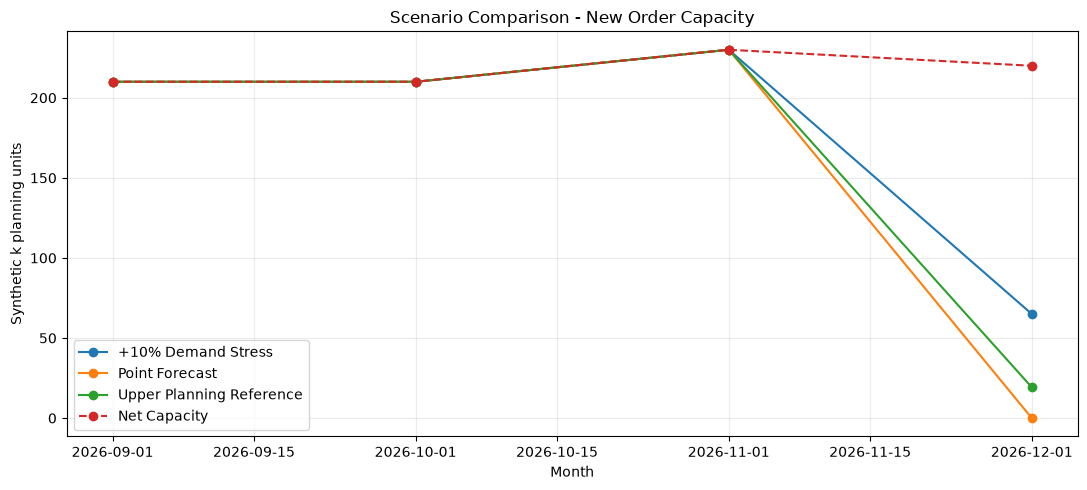

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\06_scenario_capacity_comparison.png


In [15]:
scenario_capacity_plot = pd.concat(
    [
        point_capacity_result.assign(
            scenario="Point Forecast"
        ),
        upper_capacity_result.assign(
            scenario=(
                "Upper Planning Reference"
            )
        ),
        stress_capacity_result.assign(
            scenario="+10% Demand Stress"
        ),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

for scenario_name, group in (
    scenario_capacity_plot
    .groupby("scenario")
):
    ax.plot(
        group["month"],
        group[
            "allocated_new_orders"
        ],
        marker="o",
        label=scenario_name,
    )

ax.plot(
    capacity_plan["month"],
    capacity_plan[
        "net_new_order_capacity"
    ],
    marker="o",
    linestyle="--",
    label="Net Capacity",
)

ax.set_title(
    "Scenario Comparison - New Order Capacity"
)
ax.set_xlabel("Month")
ax.set_ylabel(
    "Synthetic k planning units"
)
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "06_scenario_capacity_comparison.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

三種 Scenario 的月度 Allocation：

| Month | Point | Upper | +10% Stress | Net Capacity |
|---|---:|---:|---:|---:|
| Sep | 210 | 210 | 210 | 210 |
| Oct | 210 | 210 | 210 | 210 |
| Nov | 230 | 230 | 230 | 230 |
| Dec | **0** | **19.24** | **65.00** | 220 |

### 白話解讀

Sep～Nov 在三個 Scenario 都已經被填滿，因此 Demand 增加後無法再塞進原 Requested Planning Window，只能往 12 月移動。

Demand 越高：

- December Spillover 越大
- 對 Requested Due Month 的延遲 Quantity 越高

因此這張圖直接呈現：

> Forecast Upside 如何轉成 Capacity Spillover，再轉成 Commit Month 延後。

**下一步：**整合 Forecast Model、Bias 與 Scenario Late Result，建立最終 Decision Summary。


## Step 16｜建立 Planner Decision Summary

### 這一格要做什麼？

整合：

- Point Forecast Model
- Backtest WAPE
- Historical Bias
- Upper Reference Multiplier
- 各 Scenario Late Order Count
- 最終 Planning Interpretation

### 為什麼需要這張表？

前面每一步提供不同證據。最後的 Decision Summary 將 Forecast Quality 與 Capacity Sensitivity 放在同一個視角。


In [16]:
def get_eval_value(metric_name: str):

    matched = evaluation_summary.loc[
        evaluation_summary["metric"]
        .eq(metric_name),
        "value",
    ]

    if matched.empty:
        return "N/A"

    return matched.iloc[0]


point_late_orders = int(
    scenario_summary.loc[
        scenario_summary["scenario"]
        .eq("Point Forecast"),
        "late_orders",
    ].iloc[0]
)

upper_late_orders = int(
    scenario_summary.loc[
        scenario_summary["scenario"]
        .eq(
            "Upper Planning Reference"
        ),
        "late_orders",
    ].iloc[0]
)

stress_late_orders = int(
    scenario_summary.loc[
        scenario_summary["scenario"]
        .eq("+10% Demand Stress"),
        "late_orders",
    ].iloc[0]
)

planner_decision_summary = pd.DataFrame(
    {
        "metric": [
            "Point Forecast Model",
            "Pooled Backtest WAPE",
            "Historical Aggregate Bias",
            "Upper Reference Demand Multiplier",
            "Point Scenario Late Orders",
            "Upper Reference Late Orders",
            "+10% Stress Late Orders",
            "Planning Interpretation",
        ],
        "value": [
            get_eval_value(
                "Selected Model"
            ),
            get_eval_value(
                "Pooled Backtest WAPE"
            ),
            get_eval_value(
                "Aggregate Bias"
            ),
            (
                f"{UPPER_REFERENCE_MULTIPLIER:.4f}"
            ),
            point_late_orders,
            upper_late_orders,
            stress_late_orders,
            (
                "Use point forecast for the base plan; "
                "review upper-reference and stress scenarios "
                "before committing delivery when capacity slack is low."
            ),
        ],
    }
)

display(
    planner_decision_summary
)


,metric,value
0,Point Forecast Model,last_value
1,Pooled Backtest WAPE,1.851%
2,Historical Aggregate Bias,-1.80%
3,Upper Reference Demand Multiplier,1.0296
4,Point Scenario Late Orders,0
5,Upper Reference Late Orders,2
6,+10% Stress Late Orders,2
7,Planning Interpretation,Use point forecast for the base plan; review u...


### 輸出解讀

最終 Decision Summary：

| Metric | Result |
|---|---|
| Point Forecast Model | **last_value** |
| Pooled Backtest WAPE | **1.851%** |
| Historical Aggregate Bias | **-1.80%** |
| Upper Reference Multiplier | **1.0296** |
| Point Scenario Late Orders | **0** |
| Upper Reference Late Orders | **2** |
| +10% Stress Late Orders | **2** |

### 白話解讀

Base Plan 在 Point Scenario 下沒有 Late Order，但 Sep～Nov Capacity 已經完全用滿，而且 O004 / O006 已經是 At Risk。

需求只提高約 **2.96%** 時：

- O004 變 Late
- O006 變 Late

+10% Stress 下仍是兩張 Late，但 Late Quantity 由 **21.37** 增加到 **96.00 k units**。

因此更完整的 Planner 判讀是：

> **Point Forecast 可作為 Base Plan，但目前 Synthetic Capacity Buffer 很低；交期承諾前需要同時查看 Upper Demand Scenario，而不能只看 Point Forecast。**

這個結論也和 05 的 Under-Forecast Bias 相互呼應：Last Value 歷史上有低估需求的傾向，因此只用 Point Forecast 可能低估 Capacity Pressure。

### 不能下的結論

這些結果不能推論：

- ASE 真實產能不足
- 真實客戶一定延誤
- 真實 Commit Date
- 真實 Delivery Risk Probability

原因是 Capacity 與 Order Book 都是 Synthetic。


## Step 17｜保存 06 Simulator 結果

### 這一格要做什麼？

保存：

- Synthetic Capacity Plan
- Synthetic Order Book
- Point Scenario Allocation
- Upper Scenario Allocation
- Stress Scenario Allocation
- Scenario Summary
- Order-level Scenario Comparison
- Planner Decision Summary

### 為什麼保存？

這些輸出可以直接供：

- README
- Dashboard
- Power BI
- 面試簡報
- Planner Case Study

使用，不需要重新執行整本 Notebook。


In [17]:
OUTPUT_FILES = {
    "synthetic_capacity_plan.csv": (
        capacity_plan
    ),
    "synthetic_order_book.csv": (
        order_book
    ),
    "point_scenario_allocation.csv": (
        point_allocation
    ),
    "point_scenario_order_summary.csv": (
        point_order_summary
    ),
    "upper_scenario_allocation.csv": (
        upper_allocation
    ),
    "upper_scenario_order_summary.csv": (
        upper_order_summary
    ),
    "stress_scenario_allocation.csv": (
        stress_allocation
    ),
    "stress_scenario_order_summary.csv": (
        stress_order_summary
    ),
    "order_fulfillment_scenario_summary.csv": (
        scenario_summary
    ),
    "order_scenario_comparison.csv": (
        order_scenario_comparison
    ),
    "planner_decision_summary.csv": (
        planner_decision_summary
    ),
}

for file_name, dataframe in (
    OUTPUT_FILES.items()
):

    output_path = (
        REPORT_TABLE_DIR
        / file_name
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print("Saved:", file_name)


Saved: synthetic_capacity_plan.csv
Saved: synthetic_order_book.csv
Saved: point_scenario_allocation.csv
Saved: point_scenario_order_summary.csv
Saved: upper_scenario_allocation.csv
Saved: upper_scenario_order_summary.csv
Saved: stress_scenario_allocation.csv
Saved: stress_scenario_order_summary.csv
Saved: order_fulfillment_scenario_summary.csv
Saved: order_scenario_comparison.csv
Saved: planner_decision_summary.csv


### 輸出解讀

11 份 Simulator 輸出全部成功保存：

```text
synthetic_capacity_plan.csv
synthetic_order_book.csv
point_scenario_allocation.csv
point_scenario_order_summary.csv
upper_scenario_allocation.csv
upper_scenario_order_summary.csv
stress_scenario_allocation.csv
stress_scenario_order_summary.csv
order_fulfillment_scenario_summary.csv
order_scenario_comparison.csv
planner_decision_summary.csv
```

# 06 最終結果

## Point Scenario

- Total Demand = **650 k units**
- Late Orders = **0**
- At Risk Orders = **2**
- Sep～Nov New-Order Capacity = **100% utilized**

## Upper Planning Reference（約 +2.96%）

- Total Demand = **669.24 k units**
- Late Orders = **2**
- Late Quantity = **21.37 k units**
- December Spillover = **19.24 k units**

## +10% Demand Stress

- Total Demand = **715 k units**
- Late Orders = **2**
- At Risk Orders = **1**
- Late Quantity = **96 k units**
- December Spillover = **65 k units**

# 整個專案的完整分析鏈

**01 Data Validation**  
→ 驗證官方資料完整性

**02 Demand vs Shipment**  
→ 判讀 Orders / Shipments Flow

**03 Backlog Analysis**  
→ 判讀 Unfilled Orders / Coverage

**04 Order Forecasting**  
→ Rolling Backtest 選擇 Forecast Model

**05 Forecast Evaluation**  
→ 分析 Bias / Horizon Risk / Historical Error

**06 Order Fulfillment Simulator**  
→ 把 Forecast 轉成 Capacity / Priority / Commit Month / What-if Decision

# 最終作品定位

這是一個：

> **Public manufacturing data + transparent forecasting + synthetic capacity planning**

的 Planner Decision Support Case Study。

核心展示能力包括：

- FCST Analysis
- Backlog Monitoring
- Forecast Validation
- Forecast Bias Interpretation
- Capacity Planning
- Priority Allocation
- Order Fulfillment
- Commitment Logic
- What-if Scenario Analysis

## Simulator 限制

- Capacity 為 Synthetic
- Customer Orders 為 Synthetic
- Due Date 只到月份
- 無 Order Release Date
- 允許 Early Production
- 無產品別 routing / cycle time / yield / setup constraint
- 無實際 machine-level capacity
- Status Rule 為透明 Rule-based Scenario，不是風險預測模型
